Loading Fisher matrix from chains/fisher_matrix_radi.txt...
Total parameters found: 8
Best mode sigma: 0.0029


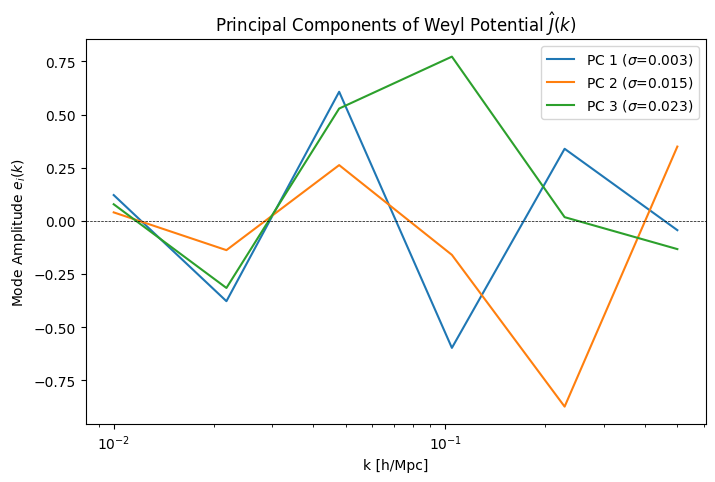

In [20]:
import numpy as np


fisher_file = "chains/fisher_matrix_radi.txt"
print(f"Loading Fisher matrix from {fisher_file}...")

with open(fisher_file, 'r') as f:
    first_line = f.readline()
    param_names = first_line.lstrip('#').strip().split()

n_params = len(param_names)
print(f"Total parameters found: {n_params}")

# 提取 J 节点索引
j_indices = [i for i, name in enumerate(param_names) if 'j_nodes--j_' in name]
F_full = np.loadtxt(fisher_file)

# --- 严谨的边缘化处理 ---
# 先全矩阵求逆得到协方差
C_full = np.linalg.inv(F_full)
# 提取目标子块
C_j = C_full[np.ix_(j_indices, j_indices)]

# --- 特征值分解 ---
# 对协方差矩阵分解：特征值 = 方差 (sigma^2)
eigvals, eigvecs = np.linalg.eigh(C_j)

# 排序：从最小方差到最大方差（信息量递减）
idx = np.argsort(eigvals)
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# --- 物理量提取 ---
sigma = np.sqrt(eigvals)
print(f"Best mode sigma: {sigma[0]:.4f}")

# --- 绘图 ---
# 确保 k_nodes 与 CosmoSIS 模块内部逻辑完全一致！
k_nodes = np.logspace(np.log10(0.01), np.log10(0.5), 6) 

plt.figure(figsize=(8, 5))
for i in range(3): # 通常前 2-3 个模式就包含了 90% 的信息
    # 模式符号归一化（可选）：确保起始点为正，方便对比
    flip = -1 if eigvecs[0, i] < 0 else 1
    plt.plot(k_nodes, flip * eigvecs[:, i], label=f"PC {i+1} ($\sigma$={sigma[i]:.3f})")

plt.xscale("log")
plt.axhline(0, color='k', lw=0.5, ls='--')
plt.xlabel("k [h/Mpc]")
plt.ylabel("Mode Amplitude $e_i(k)$")
plt.title("Principal Components of Weyl Potential $\hat{J}(k)$")
plt.legend()
plt.show()

Loading Fisher matrix from chains/fisher_matrix_radi.txt...
Total parameters found: 8
j_nodes indices: from 2 to 7
Condition number of marginalized Fisher: 1.09e+08


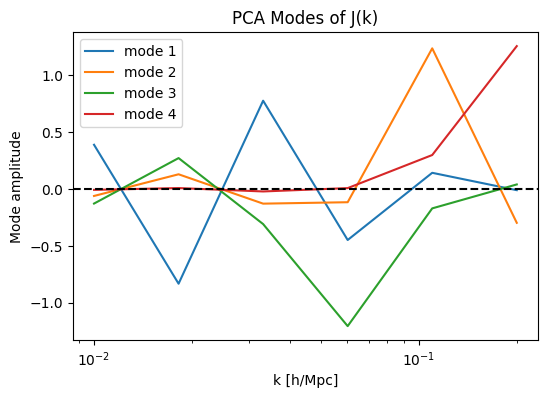

Mode errors (sigma):
[0.0005 0.0143 0.0282 0.045  0.2363 4.9182]


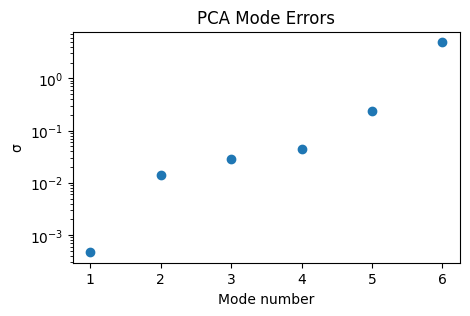

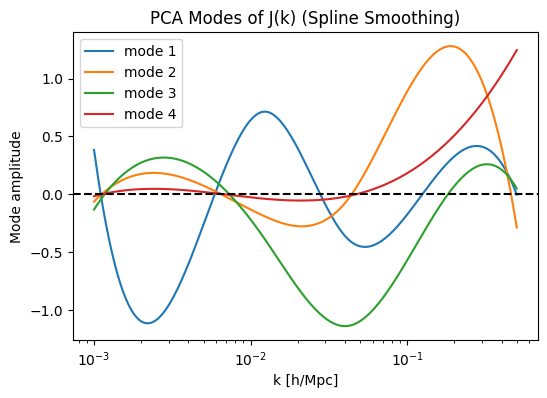

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fisher_file = "chains/fisher_matrix_radi.txt"
print(f"Loading Fisher matrix from {fisher_file}...")

with open(fisher_file, 'r') as f:
    first_line = f.readline()
    param_names = first_line.lstrip('#').strip().split()

n_params = len(param_names)
print(f"Total parameters found: {n_params}")

j_indices = [i for i, name in enumerate(param_names) if name.startswith('j_nodes--j_')]


idx_start = min(j_indices)
idx_end = max(j_indices) + 1
print(f"j_nodes indices: from {idx_start} to {idx_end-1}")

F_full = np.loadtxt(fisher_file)
if F_full.shape != (n_params, n_params):
    raise ValueError(f"Matrix shape {F_full.shape} does not match header length {n_params}.")

other = [i for i in range(n_params) if i not in j_indices]

F_jj = F_full[np.ix_(j_indices, j_indices)]
F_ja = F_full[np.ix_(j_indices, other)]
F_aj = F_full[np.ix_(other, j_indices)]
F_aa = F_full[np.ix_(other, other)]

F_j = F_jj - F_ja @ np.linalg.inv(F_aa) @ F_aj
cond = np.linalg.cond(F_j)
print(f"Condition number of marginalized Fisher: {cond:.2e}")

eigvals, eigvecs = np.linalg.eigh(F_j)
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

k_nodes = np.logspace(np.log10(0.01), np.log10(0.2), 6)
dk = np.gradient(np.log(k_nodes))

for i in range(eigvecs.shape[1]):
    norm = np.sqrt(np.sum(eigvecs[:, i]**2 * dk))
    eigvecs[:, i] /= norm

plt.figure(figsize=(6,4))
for i in range(4):
    plt.plot(k_nodes, eigvecs[:, i], label=f"mode {i+1}")
plt.axhline(0, color='k', ls='--')
plt.xscale("log")
plt.xlabel("k [h/Mpc]")
plt.ylabel("Mode amplitude")
plt.legend()
plt.title("PCA Modes of J(k)")
plt.show()

sigma = 1.0 / np.sqrt(eigvals)
print("Mode errors (sigma):")
print(sigma)

plt.figure(figsize=(5,3))
plt.plot(np.arange(1, len(sigma)+1), sigma, 'o')
plt.yscale("log")
plt.xlabel("Mode number")
plt.ylabel("σ")
plt.title("PCA Mode Errors")
plt.show()

from scipy.interpolate import UnivariateSpline

# 原来的k点（20个）
k_orig = np.logspace(np.log10(0.001), np.log10(0.5), 6)

# 创建更密集的k点用于绘图
k_dense = np.logspace(np.log10(0.001), np.log10(0.5), 200)
plt.figure(figsize=(6,4))
for i in range(4):
    # 使用样条平滑
    spline = UnivariateSpline(np.log(k_orig), eigvecs[:, i], s=0.01)  # s是平滑参数
    mode_smooth = spline(np.log(k_dense))
    
    plt.plot(k_dense, mode_smooth, label=f"mode {i+1}")

plt.axhline(0, color='k', ls='--')
plt.xscale("log")
plt.xlabel("k [h/Mpc]")
plt.ylabel("Mode amplitude")
plt.legend()
plt.title("PCA Modes of J(k) (Spline Smoothing)")
plt.show()

n_modes_keep = 3
modes_to_save = eigvecs[:, :n_modes_keep]

output_file = "pca_modes.txt"
data_out = np.column_stack((k_nodes, modes_to_save))
header = "k_h " + " ".join([f"Mode_{m+1}" for m in range(n_modes_keep)])
# np.savetxt(output_file, data_out, header=header, fmt="%.8e")
# print(f"Saved top {n_modes_keep} modes to {output_file}")

特征值下降比:
λ1/λ2 = 2.09
λ2/λ3 = 1.47
λ3/λ4 = 1.28
λ4/λ5 = 1.41
λ5/λ6 = 1.68
λ6/λ7 = 1.74
λ7/λ8 = 1.95
λ8/λ9 = 1.55
λ9/λ10 = 3.97
λ10/λ11 = 10.24
λ11/λ12 = 1130.85
λ12/λ13 = 20.69
λ13/λ14 = 45.39
λ14/λ15 = 89.57
λ15/λ16 = 69.28
λ16/λ17 = 3.64
λ17/λ18 = 5.29
λ18/λ19 = 15.85
λ19/λ20 = -1.03


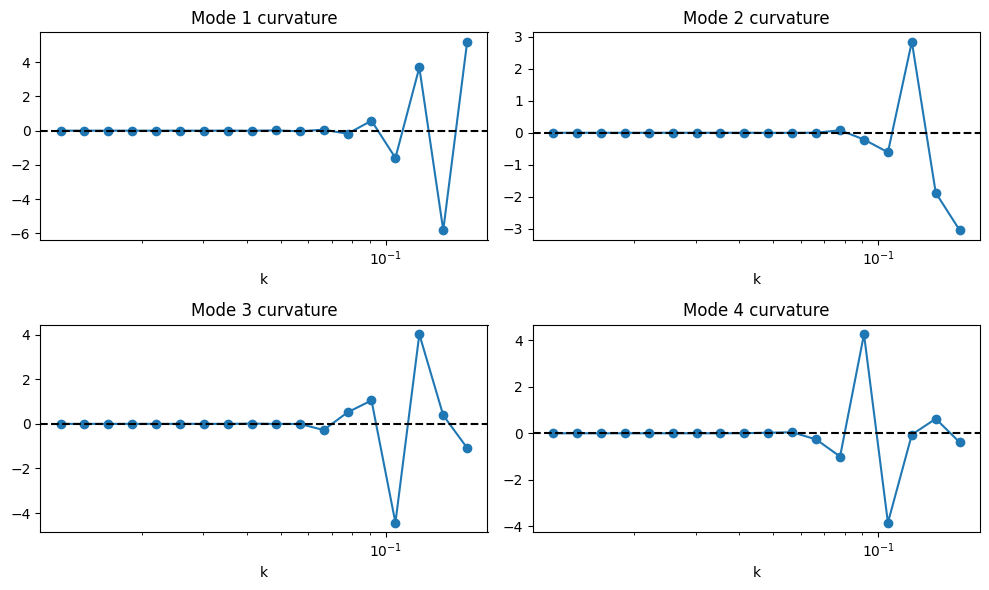

In [ ]:
# 检查特征值下降速度
print("特征值下降比:")
for i in range(len(eigvals)-1):
    ratio = eigvals[i]/eigvals[i+1]
    print(f"λ{i+1}/λ{i+2} = {ratio:.2f}")

# 如果下降很快（比如>10），说明信息主要集中在前面几个模式
# 如果下降很慢，后面的模式可能主要是噪声

# 检查特征向量的平滑度
from scipy.signal import savgol_filter

plt.figure(figsize=(10,6))
for i in range(4):
    # 计算二阶差分（曲率）
    curvature = np.diff(eigvecs[:, i], n=2)
    
    plt.subplot(2,2,i+1)
    plt.plot(k_nodes[1:-1], curvature, 'o-')
    plt.xscale("log")
    plt.axhline(0, color='k', ls='--')
    plt.title(f"Mode {i+1} curvature")
    plt.xlabel("k")
    
# 如果曲率变化剧烈且没有规律，可能有问题
plt.tight_layout()
plt.show()

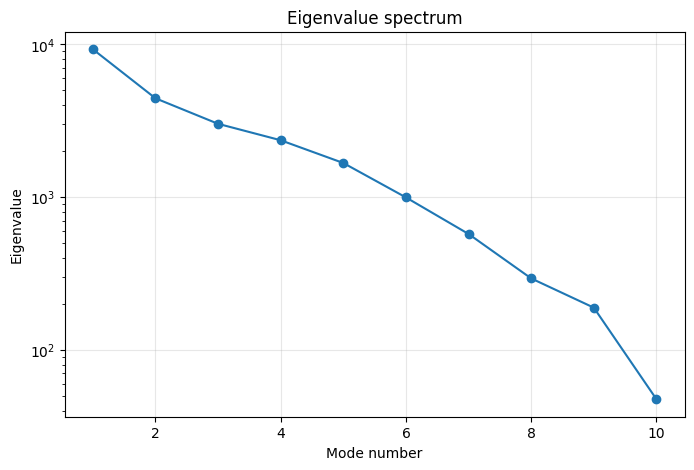

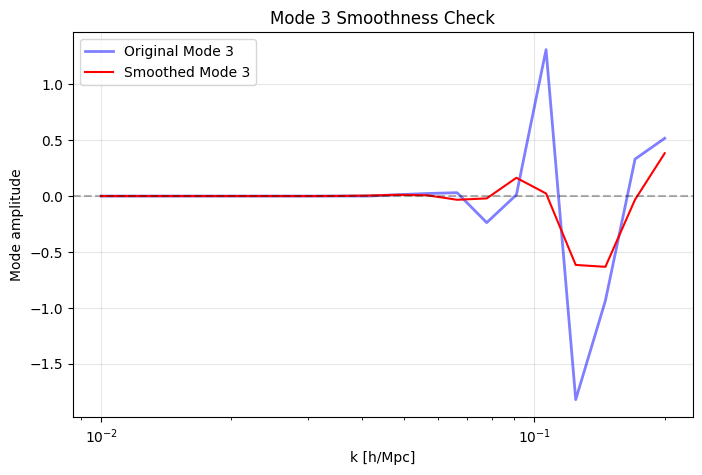

Mode orthogonality check (first 5 modes):
Should be identity matrix (1 on diagonal, 0 off-diagonal):
[[ 1.  0.  0. -0.  0.]
 [ 0.  1.  0.  0. -0.]
 [ 0.  0.  1. -0. -0.]
 [-0.  0. -0.  1.  0.]
 [ 0. -0. -0.  0.  1.]]

Max deviation from identity: 6.38e-16
✓ Excellent orthogonality


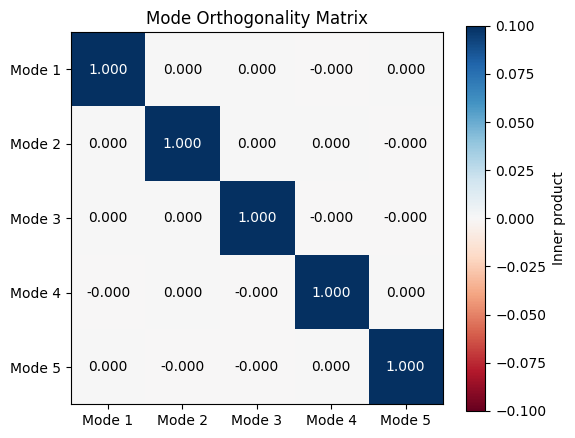


Modes needed for 95% information: 6
Modes needed for 99% information: 9


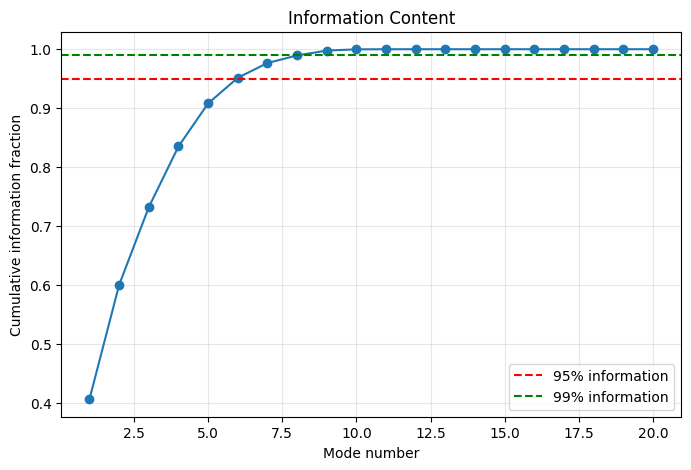

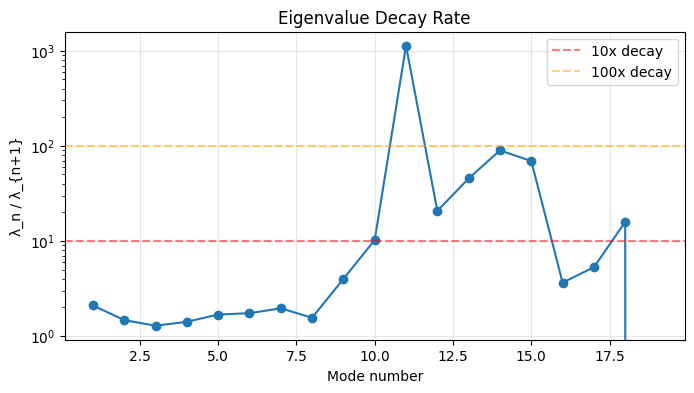

In [ ]:
# 1. 检查特征值衰减
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d

# 1. 检查特征值衰减
plt.figure(figsize=(8, 5))
plt.semilogy(range(1, min(11, len(eigvals)+1)), eigvals[:10], 'o-')
plt.xlabel('Mode number')
plt.ylabel('Eigenvalue')
plt.title('Eigenvalue spectrum')
plt.grid(True, alpha=0.3)
plt.show()
# 应该看到指数衰减，没有突然的跳跃

# 2. 检查模式平滑度（以第3个模式为例）
# 注意：modes变量应该是eigvecs，索引从0开始，所以mode 3对应索引2
mode_index = 2  # 第3个模式
mode_smooth = gaussian_filter1d(eigvecs[:, mode_index], sigma=1, mode='nearest')

plt.figure(figsize=(8, 5))
plt.plot(k_nodes, eigvecs[:, mode_index], 'b-', alpha=0.5, linewidth=2, label=f'Original Mode {mode_index+1}')
plt.plot(k_nodes, mode_smooth, 'r-', linewidth=1.5, label=f'Smoothed Mode {mode_index+1}')
plt.axhline(0, color='k', ls='--', alpha=0.3)
plt.xscale("log")
plt.xlabel("k [h/Mpc]")
plt.ylabel("Mode amplitude")
plt.legend()
plt.title(f'Mode {mode_index+1} Smoothness Check')
plt.grid(True, alpha=0.3)
plt.show()
# 如果平滑版本和原始版本差异很大，说明主要是噪声

# 3. 检查模式之间的正交性
# 取前几个模式检查
n_check = 5  # 检查前5个模式的正交性
modes_check = eigvecs[:, :n_check]

# 计算内积矩阵（应该接近单位矩阵）
orthogonality = modes_check.T @ np.diag(dk) @ modes_check

print(f"Mode orthogonality check (first {n_check} modes):")
print("Should be identity matrix (1 on diagonal, 0 off-diagonal):")
# 设置打印选项，更好地显示小数值
np.set_printoptions(precision=4, suppress=True)
print(orthogonality)

# 检查偏离单位矩阵的程度
deviation = orthogonality - np.eye(n_check)
max_deviation = np.max(np.abs(deviation))
print(f"\nMax deviation from identity: {max_deviation:.2e}")
if max_deviation < 1e-5:
    print("✓ Excellent orthogonality")
elif max_deviation < 1e-3:
    print("✓ Good orthogonality")
else:
    print("⚠ Warning: Significant deviation from orthogonality")

# 可选：可视化正交性矩阵
plt.figure(figsize=(6, 5))
plt.imshow(orthogonality, cmap='RdBu', vmin=-0.1, vmax=0.1)
plt.colorbar(label='Inner product')
plt.xticks(range(n_check), [f'Mode {i+1}' for i in range(n_check)])
plt.yticks(range(n_check), [f'Mode {i+1}' for i in range(n_check)])
plt.title('Mode Orthogonality Matrix')
for i in range(n_check):
    for j in range(n_check):
        plt.text(j, i, f'{orthogonality[i,j]:.3f}', 
                ha='center', va='center', 
                color='white' if abs(orthogonality[i,j]) > 0.05 else 'black')
plt.show()

# 4. 量化分析特征值衰减
# 计算信息占比
total_info = np.sum(eigvals)
cumulative_info = np.cumsum(eigvals) / total_info

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_info)+1), cumulative_info, 'o-')
plt.xlabel('Mode number')
plt.ylabel('Cumulative information fraction')
plt.title('Information Content')
plt.axhline(0.95, color='r', ls='--', label='95% information')
plt.axhline(0.99, color='g', ls='--', label='99% information')
plt.legend()
plt.grid(True, alpha=0.3)

# 找到达到95%和99%信息的模式数
n_95 = np.where(cumulative_info >= 0.95)[0][0] + 1
n_99 = np.where(cumulative_info >= 0.99)[0][0] + 1
print(f"\nModes needed for 95% information: {n_95}")
print(f"Modes needed for 99% information: {n_99}")
plt.show()

# 5. 检查特征值衰减率
# 计算相邻特征值的比值
ratio = eigvals[:-1] / eigvals[1:]
plt.figure(figsize=(8, 4))
plt.semilogy(range(1, len(ratio)+1), ratio, 'o-')
plt.xlabel('Mode number')
plt.ylabel('λ_n / λ_{n+1}')
plt.title('Eigenvalue Decay Rate')
plt.grid(True, alpha=0.3)
plt.axhline(10, color='r', ls='--', alpha=0.5, label='10x decay')
plt.axhline(100, color='orange', ls='--', alpha=0.5, label='100x decay')
plt.legend()
plt.show()